In [52]:
import numpy as np
import matplotlib.pyplot as plt



In [53]:
# Load CSV files into separate NumPy arrays
node1 = np.loadtxt("N001_024.csv", delimiter=',')  # Node 1 data
node2 = np.loadtxt("N002_024.csv", delimiter=',')  # Node 2 data
node3 = np.loadtxt("N003_024.csv", delimiter=',')  # Node 3 data
node4 = np.loadtxt("N004_024.csv", delimiter=',')  # Node 4 data

gateway = np.loadtxt("N100_024.csv", delimiter=',')  # Gateway data

# Print the shape of each data array
print("node1 shape:", node1.shape)
print("node2 shape:", node2.shape)
print("node3 shape:", node3.shape)
print("node4 shape:", node4.shape)

print("gateway shape:", gateway.shape)


node1 shape: (3000, 4)
node2 shape: (3000, 4)
node3 shape: (3000, 4)
node4 shape: (3000, 4)
gateway shape: (3000, 4)


In [54]:
node1_z = node1[:, 3]  # Extract z-coordinates from node1
node2_z = node2[:, 3]  # Extract z-coordinates from node2
node3_z = node3[:, 3]  # Extract z-coordinates from node3
node4_z = node4[:, 3]  # Extract z-coordinates from node4

gateway_z = gateway[:, 3]  # Extract z-coordinates from gateway

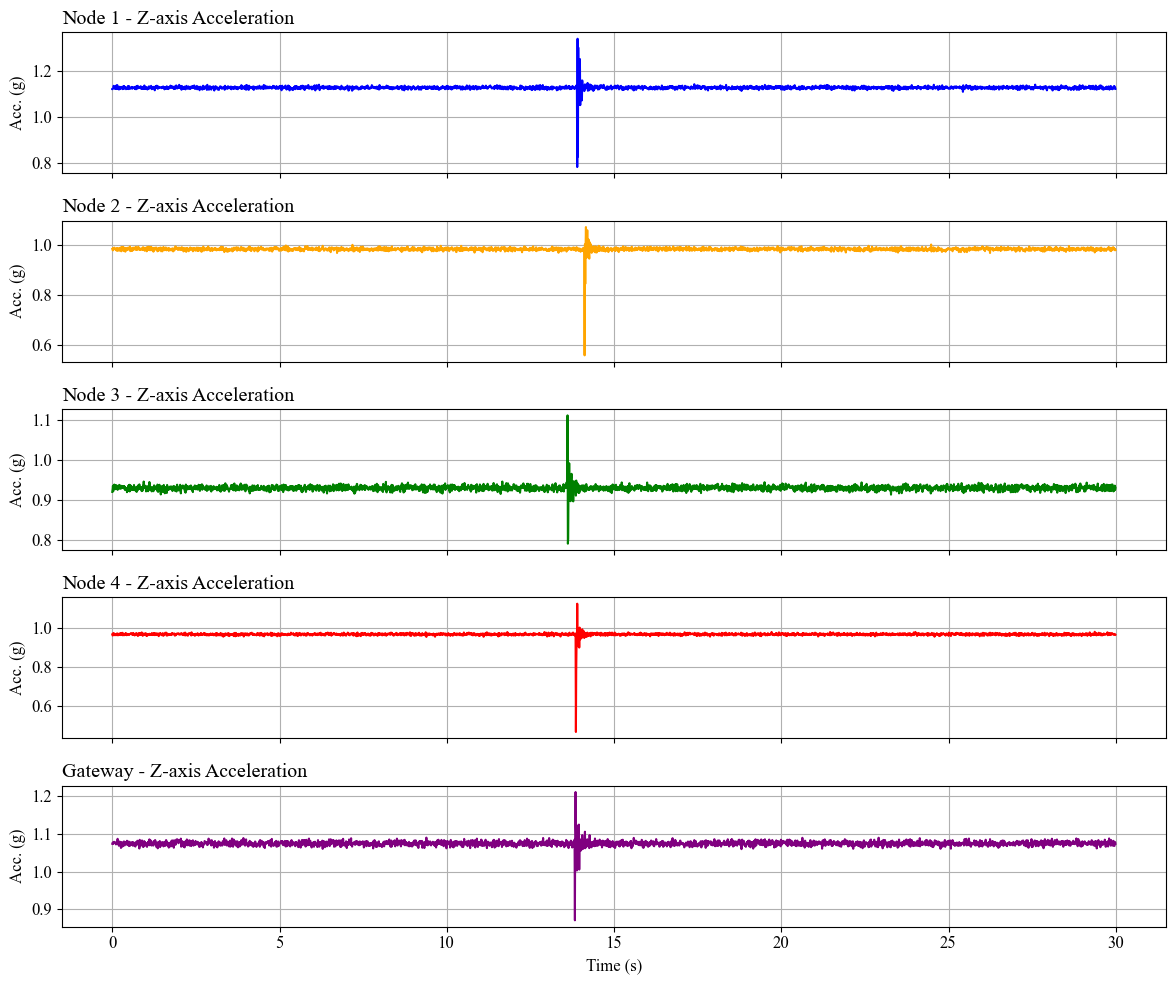

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12  # Base font size

# Sampling frequency and time step
fs = 100  # Hz
dt = 1 / fs

# Generate time vectors
t1 = np.arange(len(node1_z)) * dt
t2 = np.arange(len(node2_z)) * dt
t3 = np.arange(len(node3_z)) * dt
t4 = np.arange(len(node4_z)) * dt
t_gw = np.arange(len(gateway_z)) * dt

# Create figure and axes
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

# Plot each signal with title
axes[0].plot(t1, node1_z, color='blue')
axes[0].set_title("Node 1 - Z-axis Acceleration", loc='left')

axes[1].plot(t2, node2_z, color='orange')
axes[1].set_title("Node 2 - Z-axis Acceleration", loc='left')

axes[2].plot(t3, node3_z, color='green')
axes[2].set_title("Node 3 - Z-axis Acceleration", loc='left')

axes[3].plot(t4, node4_z, color='red')
axes[3].set_title("Node 4 - Z-axis Acceleration", loc='left')

axes[4].plot(t_gw, gateway_z, color='purple')
axes[4].set_title("Gateway - Z-axis Acceleration", loc='left')

# Set Y labels
for ax in axes:
    ax.set_ylabel("Acc. (g)")
    ax.grid(True)

# Set X label for the last subplot
axes[-1].set_xlabel("Time (s)")

# Adjust layout
plt.tight_layout(h_pad=1.2)
plt.show()


Node 1 lag: 90.00 ms (9 samples)
Node 2 lag: 290.00 ms (29 samples)
Node 3 lag: -210.00 ms (-21 samples)
Node 4 lag: 30.00 ms (3 samples)


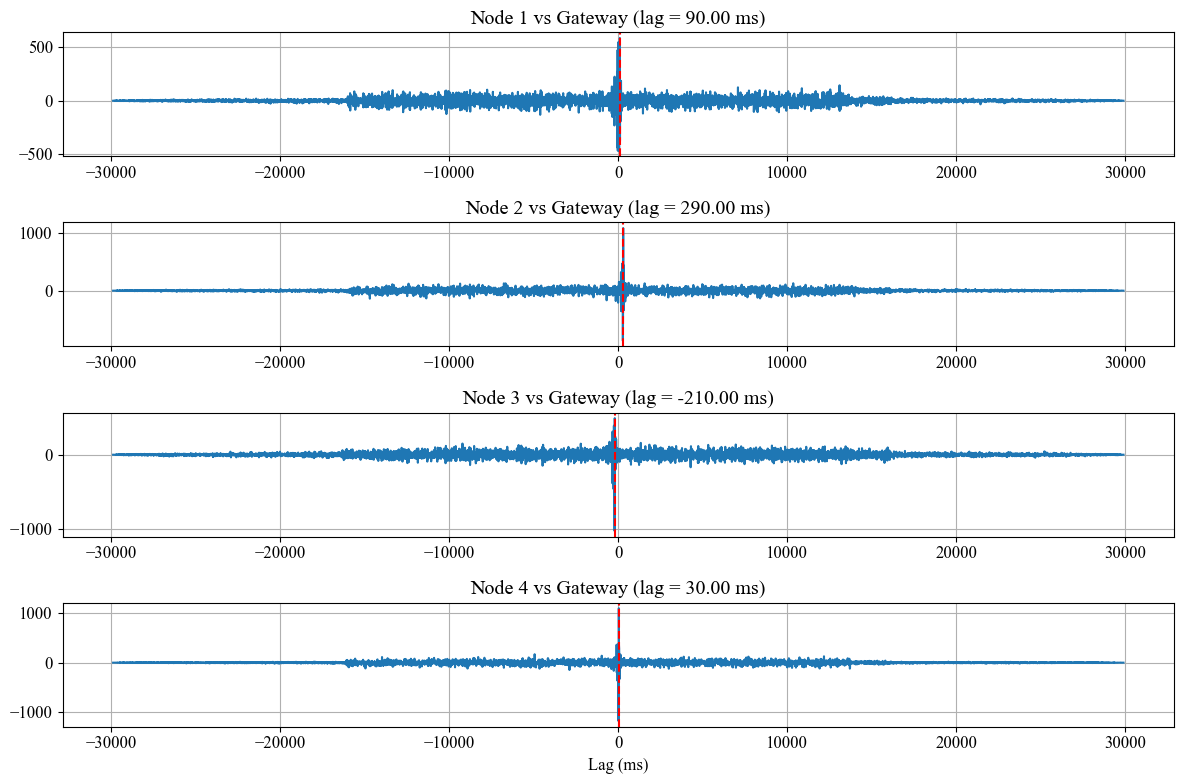

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# === Parameters ===
fs = 100  # Sampling frequency in Hz
dt = 1 / fs
cut_start = 10  # Remove initial inaccurate points

# === Step 1: Extract Z-axis from each node ===
node1_z = node1[:, 3]
node2_z = node2[:, 3]
node3_z = node3[:, 3]
node4_z = node4[:, 3]
gateway_z = gateway[:, 3]

# === Step 2: Remove first 10 points ===
node1_z = node1_z[cut_start:]
node2_z = node2_z[cut_start:]
node3_z = node3_z[cut_start:]
node4_z = node4_z[cut_start:]
gateway_z = gateway_z[cut_start:]

# === Step 3: Truncate to minimum length ===
min_len = min(len(gateway_z), len(node1_z), len(node2_z), len(node3_z), len(node4_z))
gateway_z = gateway_z[:min_len]
node1_z = node1_z[:min_len]
node2_z = node2_z[:min_len]
node3_z = node3_z[:min_len]
node4_z = node4_z[:min_len]

# === Step 4: Normalize signals ===
def normalize(sig):
    return (sig - np.mean(sig)) / np.std(sig)

gateway_z_n = normalize(gateway_z)
node1_z_n = normalize(node1_z)
node2_z_n = normalize(node2_z)
node3_z_n = normalize(node3_z)
node4_z_n = normalize(node4_z)

# === Step 5: Compute lag using cross-correlation ===
def compute_lag(sig_a, sig_b, fs):
    corr = correlate(sig_b, sig_a, mode='full')  # lag = when sig_b aligns best with sig_a
    lags = np.arange(-len(sig_a) + 1, len(sig_b))
    max_idx = np.argmax(corr)
    lag_samples = lags[max_idx]
    lag_seconds = lag_samples / fs
    return lag_seconds, lag_samples, corr, lags

# === Step 6: Calculate lags ===
lag1, lag1_samples, corr1, lags1 = compute_lag(gateway_z_n, node1_z_n, fs)
lag2, lag2_samples, corr2, lags2 = compute_lag(gateway_z_n, node2_z_n, fs)
lag3, lag3_samples, corr3, lags3 = compute_lag(gateway_z_n, node3_z_n, fs)
lag4, lag4_samples, corr4, lags4 = compute_lag(gateway_z_n, node4_z_n, fs)

# === Step 7: Output results in milliseconds ===
print(f"Node 1 lag: {lag1 * 1000:.2f} ms ({lag1_samples} samples)")
print(f"Node 2 lag: {lag2 * 1000:.2f} ms ({lag2_samples} samples)")
print(f"Node 3 lag: {lag3 * 1000:.2f} ms ({lag3_samples} samples)")
print(f"Node 4 lag: {lag4 * 1000:.2f} ms ({lag4_samples} samples)")

# === Step 8: Plot cross-correlation for visual check (in milliseconds) ===
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot((lags1 / fs) * 1000, corr1)
plt.axvline(lag1 * 1000, color='red', linestyle='--')
plt.title(f'Node 1 vs Gateway (lag = {lag1 * 1000:.2f} ms)')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot((lags2 / fs) * 1000, corr2)
plt.axvline(lag2 * 1000, color='red', linestyle='--')
plt.title(f'Node 2 vs Gateway (lag = {lag2 * 1000:.2f} ms)')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot((lags3 / fs) * 1000, corr3)
plt.axvline(lag3 * 1000, color='red', linestyle='--')
plt.title(f'Node 3 vs Gateway (lag = {lag3 * 1000:.2f} ms)')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot((lags4 / fs) * 1000, corr4)
plt.axvline(lag4 * 1000, color='red', linestyle='--')
plt.title(f'Node 4 vs Gateway (lag = {lag4 * 1000:.2f} ms)')
plt.xlabel("Lag (ms)")
plt.grid(True)

plt.tight_layout()

plt.savefig("cross_correlation_lags.png", dpi=300)
plt.show()

